In [1]:

from pathlib import Path
import sys, json, shutil, math, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Audio

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw' / 'for-2sec'
PROCESSED_DIR = DATA_DIR / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
TABLES_DIR = REPORTS_DIR / 'tables'
WEB_APP_DIR = PROJECT_ROOT / 'web_app'
WEB_GENERATED_DIR = WEB_APP_DIR / 'assets' / 'generated' / 'figures'
WEB_AUDIO_DIR = WEB_APP_DIR / 'assets' / 'generated' / 'audio'
RESULTS_JS_FILE = WEB_APP_DIR / 'assets' / 'js' / 'results-data.js'
RESULTS_JSON_FILE = WEB_APP_DIR / 'assets' / 'generated' / 'results-data.json'
FEATURE_FILE = PROCESSED_DIR / 'single_notebook_stft_rnn_features.npz'

for folder in [PROCESSED_DIR, MODELS_DIR, FIGURES_DIR, TABLES_DIR, WEB_GENERATED_DIR, WEB_AUDIO_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

SAMPLE_RATE = 16000
DURATION_SECONDS = 2.0
N_FFT = 1024
HOP_LENGTH = 256
MAX_TRAIN_SAMPLES = 4000
MAX_VALIDATION_SAMPLES = 800
MAX_TEST_SAMPLES = 800
EPOCHS = 12
BATCH_SIZE = 32
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

STYLE = """
<style>
.nb-hero{background:linear-gradient(135deg,#253039,#2f3942);color:white;border-radius:16px;padding:28px;margin:16px 0 24px}.nb-hero h1{margin:0 0 10px;font-size:2rem;line-height:1.2}.nb-hero p{margin:0;line-height:1.65;opacity:.95}.nb-section{background:white;border:1px solid #d8dde6;border-left:6px solid #007bff;padding:18px 20px;border-radius:12px;margin:22px 0 14px}.nb-section h2{margin:0 0 6px;color:#253039}.nb-section p{margin:0;color:#6b7280;line-height:1.6}.nb-card{background:white;border:1px solid #d8dde6;padding:18px 20px;border-radius:12px;margin:14px 0}.nb-card.good{background:#effaf1;border-color:#c7eecb}.nb-card.warn{background:#fff8e5;border-color:#ead8a6}.nb-grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(180px,1fr));gap:12px;margin:14px 0}.nb-metric{background:white;border:1px solid #d8dde6;border-radius:12px;padding:14px 16px}.nb-metric span{display:block;color:#6b7280;font-size:.78rem;text-transform:uppercase;letter-spacing:.06em;font-weight:800}.nb-metric strong{display:block;margin-top:5px;font-size:1.45rem;color:#253039}.nb-table-card{background:white;border:1px solid #d8dde6;border-radius:12px;padding:16px;margin:14px 0;overflow-x:auto}.nb-table{border-collapse:collapse;width:100%}.nb-table th{background:#253039;color:white;text-align:left;padding:10px 12px}.nb-table td{border-bottom:1px solid #d8dde6;padding:10px 12px}.nb-table tr:nth-child(even) td{background:#f8fafc}.nb-step{background:#f8fafc;border:1px solid #d8dde6;border-radius:12px;padding:16px;margin:10px 0}.nb-step b{color:#007bff}
</style>
"""
display(HTML(STYLE))

def hero(title, subtitle):
    display(HTML(f"<div class='nb-hero'><h1>{title}</h1><p>{subtitle}</p><p><b>Created by: Bob Mathew Sunga</b></p></div>"))
def section(title, subtitle=''):
    display(HTML(f"<div class='nb-section'><h2>{title}</h2><p>{subtitle}</p></div>"))
def card(title, body, kind=''):
    display(HTML(f"<div class='nb-card {kind}'><h3>{title}</h3>{body}</div>"))
def metrics(items):
    html=''.join([f"<div class='nb-metric'><span>{x['label']}</span><strong>{x['value']}</strong><small>{x.get('note','')}</small></div>" for x in items])
    display(HTML(f"<div class='nb-grid'>{html}</div>"))
def show_df(df, title='', subtitle=''):
    display(HTML(f"<div class='nb-table-card'><h3>{title}</h3><p>{subtitle}</p>{df.to_html(index=False,classes='nb-table',escape=False)}</div>"))

hero('RNN-Based Audio Deepfake Detection Using FFT-Derived STFT Features', 'Single notebook that trains/evaluates seven RNN architectures, generates confusion matrices, creates audio/STFT visualizations, and exports the exact same values to the web application.')


In [2]:

# 01. Dataset check
section('01. Dataset Folder Check', 'Place the Kaggle Fake-or-Real for-2sec dataset inside data/raw/for-2sec before running the notebook.')
AUDIO_EXTS = ['.wav', '.mp3', '.flac', '.ogg', '.m4a']
required = [RAW_DIR/'training'/'real', RAW_DIR/'training'/'fake', RAW_DIR/'validation'/'real', RAW_DIR/'validation'/'fake', RAW_DIR/'testing'/'real', RAW_DIR/'testing'/'fake']
folder_df = pd.DataFrame([{'Folder': str(p.relative_to(PROJECT_ROOT)), 'Status': 'FOUND' if p.exists() else 'MISSING'} for p in required])
show_df(folder_df, 'Required Dataset Folders')

def count_audio(folder):
    return sum(len(list(Path(folder).glob(f'*{ext}'))) for ext in AUDIO_EXTS) if Path(folder).exists() else 0

def collect(split):
    rows=[]
    for class_name,label in [('real',0),('fake',1)]:
        folder=RAW_DIR/split/class_name
        if not folder.exists(): continue
        for ext in AUDIO_EXTS:
            for fp in folder.glob(f'*{ext}'):
                rows.append({'file_path':str(fp),'file_name':fp.name,'split':split,'class_name':class_name,'label':label})
    return pd.DataFrame(rows)

dataset_summary = pd.DataFrame([{'Split':split,'Class':cls,'Count':count_audio(RAW_DIR/split/cls)} for split in ['training','validation','testing'] for cls in ['real','fake']])
show_df(dataset_summary, 'Dataset File Counts')
train_df, validation_df, test_df = collect('training'), collect('validation'), collect('testing')
metrics([{'label':'Training Files','value':f'{len(train_df):,}'},{'label':'Validation Files','value':f'{len(validation_df):,}'},{'label':'Testing Files','value':f'{len(test_df):,}'}])
if len(train_df)==0 or len(validation_df)==0 or len(test_df)==0:
    card('Dataset Not Found Yet', '<p>Download the Fake-or-Real dataset and copy the for-2sec folder into data/raw/for-2sec. The web app can open with preview values, but the notebook needs the dataset to train and export real outputs.</p>', 'warn')


Folder,Status
data\raw\for-2sec\training\real,FOUND
data\raw\for-2sec\training\fake,FOUND
data\raw\for-2sec\validation\real,FOUND
data\raw\for-2sec\validation\fake,FOUND
data\raw\for-2sec\testing\real,FOUND
data\raw\for-2sec\testing\fake,FOUND


Split,Class,Count
training,real,6978
training,fake,6978
validation,real,1413
validation,fake,1413
testing,real,544
testing,fake,544


In [3]:

# 01B. Detailed dataset methodology and decision rules
section('01B. Detailed Dataset Methodology', 'This section explains how the dataset is prepared before any model training occurs.')

card('Dataset choice: Fake-or-Real for-2sec subset', '''
<p>The project uses the <strong>Fake-or-Real</strong> audio dataset, specifically the <code>for-2sec</code> subset. This subset is appropriate for the current experiment because every sample is already prepared as a short two-second audio clip. That makes the experiment more controlled because each model receives audio with the same duration.</p>
<p>Using fixed-duration samples is important for a Recurrent Neural Network, or <strong>RNN</strong>, because each sample must be converted into a sequence of comparable length. If one audio file is much longer than another, the extracted Short-Time Fourier Transform, or <strong>STFT</strong>, sequence will also be longer. The two-second subset reduces this issue and makes the sequence preparation more consistent.</p>
''', 'good')

card('Folder validation methodology', '''
<p>The notebook first checks whether the expected folders exist for training, validation, and testing. Each split must contain a <code>real</code> folder and a <code>fake</code> folder. The folder check prevents the notebook from silently training on incomplete data or accidentally mixing real and fake samples.</p>
<p>The expected structure is: <code>training/real</code>, <code>training/fake</code>, <code>validation/real</code>, <code>validation/fake</code>, <code>testing/real</code>, and <code>testing/fake</code>. The notebook treats real audio as label <strong>0</strong> and fake audio as label <strong>1</strong>.</p>
''')

card('Sampling methodology', '''
<p>The full dataset can be large and training seven RNN architectures can take time. For this reason, the notebook uses a balanced sample for training, validation, and testing. Balanced sampling means the notebook tries to use the same number of real and fake samples in each split.</p>
<p>This is important because an imbalanced dataset can make accuracy misleading. In this project, balanced sampling makes the comparison between real and fake audio detection more reliable.</p>
''')

methodology_table = pd.DataFrame([
    {'Stage': 'Folder check', 'Purpose': 'Confirm that all real/fake split folders exist before processing.'},
    {'Stage': 'Label assignment', 'Purpose': 'Assign 0 to real audio and 1 to fake audio for binary classification.'},
    {'Stage': 'Balanced sampling', 'Purpose': 'Keep class distribution fair across training, validation, and testing.'},
    {'Stage': 'Train split', 'Purpose': 'Used by the model to learn sequence patterns.'},
    {'Stage': 'Validation split', 'Purpose': 'Used for threshold tuning and training decisions.'},
    {'Stage': 'Test split', 'Purpose': 'Used only for final evaluation after training.'},
])
show_df(methodology_table, 'Dataset Methodology Summary')


Stage,Purpose
Folder check,Confirm that all real/fake split folders exist before processing.
Label assignment,Assign 0 to real audio and 1 to fake audio for binary classification.
Balanced sampling,"Keep class distribution fair across training, validation, and testing."
Train split,Used by the model to learn sequence patterns.
Validation split,Used for threshold tuning and training decisions.
Test split,Used only for final evaluation after training.


In [4]:

# 02. Sample dataset and explain the pipeline
section('02. Research Pipeline', 'The same notebook will export all values and figures to the web app, so both outputs stay synchronized.')
steps = [
    ('Load audio', 'Read real and fake 2-second audio clips.'),
    ('Normalize waveform', 'Resample and pad or trim every clip to the same duration.'),
    ('Generate waveform plots', 'Show the time-domain difference between real and fake samples.'),
    ('Apply STFT', 'Use FFT windows to convert audio into time-frequency frames.'),
    ('Prepare RNN input', 'Use samples × time frames × frequency bins as the recurrent input.'),
    ('Train seven RNN architectures', 'Evaluate Basic GRU, GRU + Dropout, Stacked GRU, BiGRU, BiGRU + LayerNorm, BiGRU + Attention, and BiLSTM + Attention.'),
    ('Tune threshold', 'Find the threshold that maximizes validation F1-score.'),
    ('Analyze errors', 'Use confusion matrices, false positives, false negatives, ROC curves, and probability distributions.')
]
for i,(a,b) in enumerate(steps,1):
    display(HTML(f"<div class='nb-step'><b>{i}. {a}</b><br>{b}</div>"))

def balanced_sample(df, max_samples, seed=RANDOM_SEED):
    if df.empty: return df
    if max_samples is None or len(df)<=max_samples:
        return df.sample(frac=1, random_state=seed).reset_index(drop=True)
    per=max_samples//2
    parts=[]
    for label in sorted(df['label'].unique()):
        part=df[df['label']==label]
        parts.append(part.sample(n=min(per,len(part)), random_state=seed))
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

train_sample_df = balanced_sample(train_df, MAX_TRAIN_SAMPLES)
validation_sample_df = balanced_sample(validation_df, MAX_VALIDATION_SAMPLES)
test_sample_df = balanced_sample(test_df, MAX_TEST_SAMPLES)
metrics([{'label':'Train Used','value':f'{len(train_sample_df):,}'},{'label':'Validation Used','value':f'{len(validation_sample_df):,}'},{'label':'Test Used','value':f'{len(test_sample_df):,}'}])


In [5]:

# 02B. Detailed research pipeline methodology
section('02B. Detailed Research Pipeline Methodology', 'This section explains the full process from raw audio to final dashboard export.')

pipeline_table = pd.DataFrame([
    {'Step': '1. Load audio', 'Detailed Methodology': 'Each audio file is loaded from the dataset folders. The notebook keeps the source filename so later visualizations and error analysis can refer back to the original sample.'},
    {'Step': '2. Standardize duration', 'Detailed Methodology': 'Every sample is forced into a consistent two-second duration. Shorter samples are padded and longer samples are trimmed. This keeps the RNN input shape consistent.'},
    {'Step': '3. Generate waveform visualization', 'Detailed Methodology': 'The waveform shows amplitude over time. This helps explain the raw signal before converting it into frequency-domain features.'},
    {'Step': '4. Extract STFT sequence', 'Detailed Methodology': 'The Short-Time Fourier Transform breaks the audio into overlapping windows and applies Fourier analysis to each window. The result is a time-frequency matrix.'},
    {'Step': '5. Prepare RNN input', 'Detailed Methodology': 'The STFT matrix is transposed into time frames by frequency bins. This creates the shape samples × time frames × frequency bins.'},
    {'Step': '6. Train seven RNN architectures', 'Detailed Methodology': 'The experiment trains Basic GRU, GRU + Dropout, Stacked GRU, BiGRU, BiGRU + Dropout + LayerNorm, BiGRU + Attention, and BiLSTM + Attention.'},
    {'Step': '7. Tune decision threshold', 'Detailed Methodology': 'Each architecture is evaluated with a default threshold and a validation-tuned threshold. The threshold is an evaluation setting, not a separate model.'},
    {'Step': '8. Evaluate and export', 'Detailed Methodology': 'The notebook exports metrics, confusion matrices, figures, and result data to the web application so the dashboard values match the notebook output.'},
])
show_df(pipeline_table, 'Detailed Research Pipeline')

card('Why the notebook exports to the dashboard', '''
<p>The web application should not contain manually typed values that can drift away from the notebook results. This notebook exports a JavaScript data file after training and evaluation. The web app reads that exported file, so the dashboard values, tables, confusion matrices, and figures match the notebook output.</p>
''', 'good')


Step,Detailed Methodology
1. Load audio,Each audio file is loaded from the dataset folders. The notebook keeps the source filename so later visualizations and error analysis can refer back to the original sample.
2. Standardize duration,Every sample is forced into a consistent two-second duration. Shorter samples are padded and longer samples are trimmed. This keeps the RNN input shape consistent.
3. Generate waveform visualization,The waveform shows amplitude over time. This helps explain the raw signal before converting it into frequency-domain features.
4. Extract STFT sequence,The Short-Time Fourier Transform breaks the audio into overlapping windows and applies Fourier analysis to each window. The result is a time-frequency matrix.
5. Prepare RNN input,The STFT matrix is transposed into time frames by frequency bins. This creates the shape samples × time frames × frequency bins.
6. Train seven RNN architectures,"The experiment trains Basic GRU, GRU + Dropout, Stacked GRU, BiGRU, BiGRU + Dropout + LayerNorm, BiGRU + Attention, and BiLSTM + Attention."
7. Tune decision threshold,"Each architecture is evaluated with a default threshold and a validation-tuned threshold. The threshold is an evaluation setting, not a separate model."
8. Evaluate and export,"The notebook exports metrics, confusion matrices, figures, and result data to the web application so the dashboard values match the notebook output."


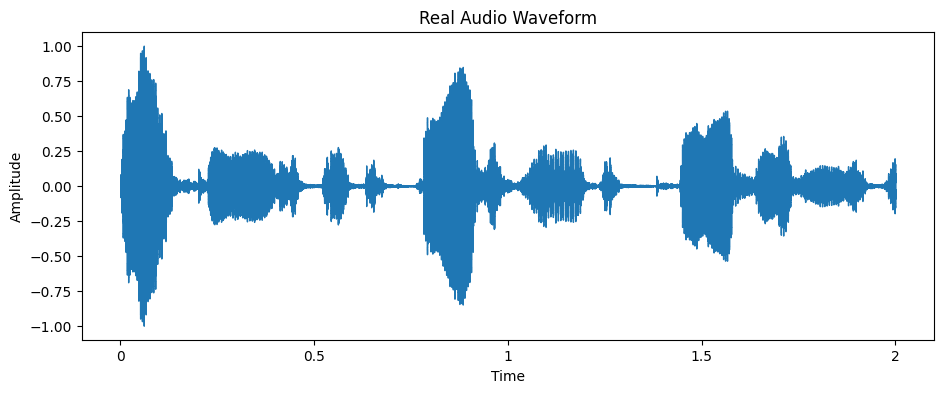

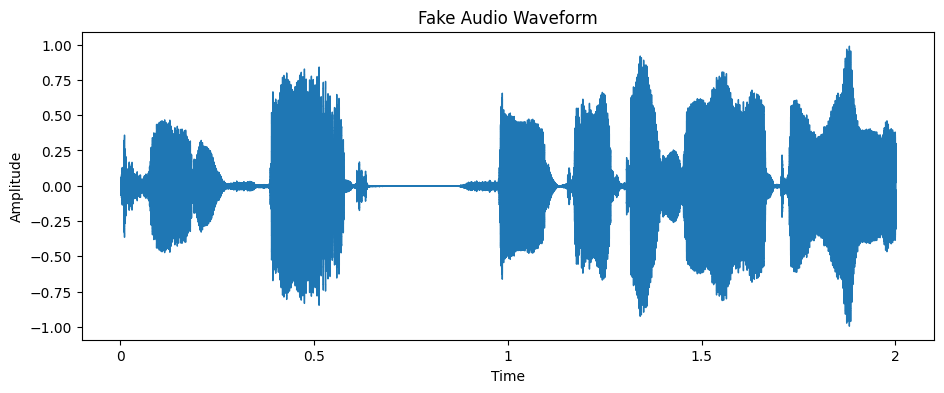

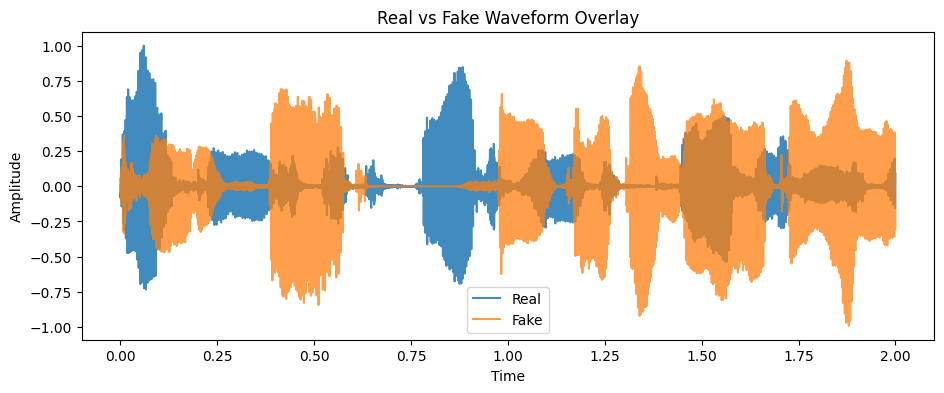

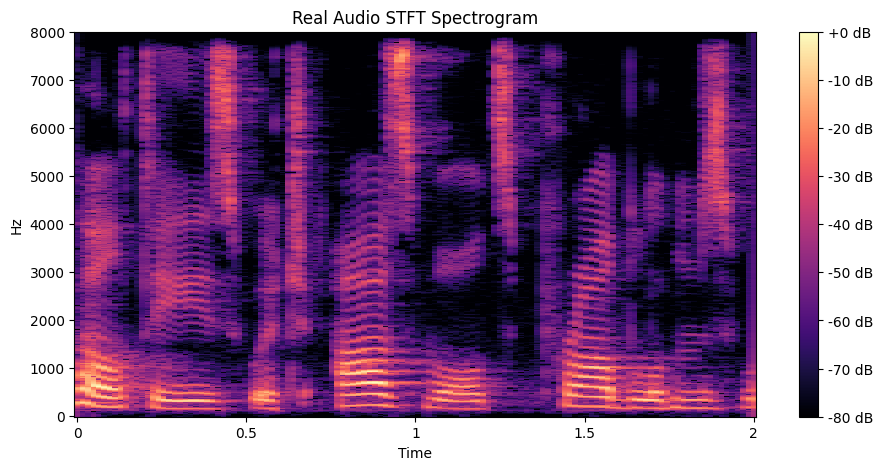

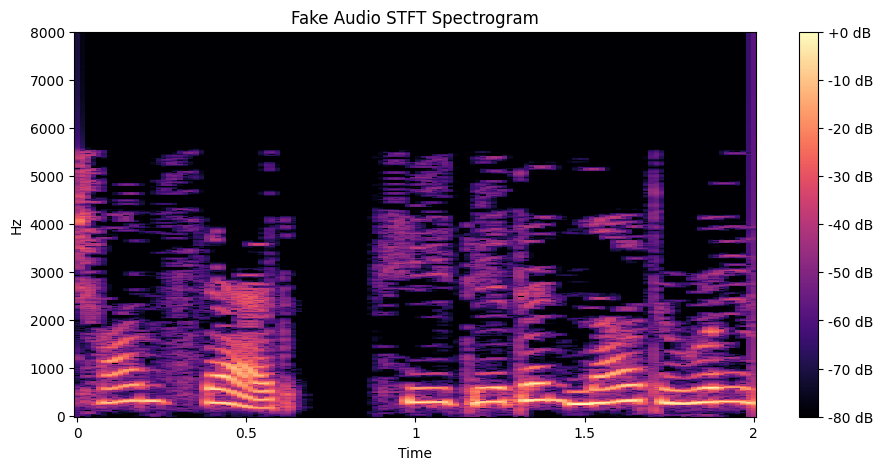

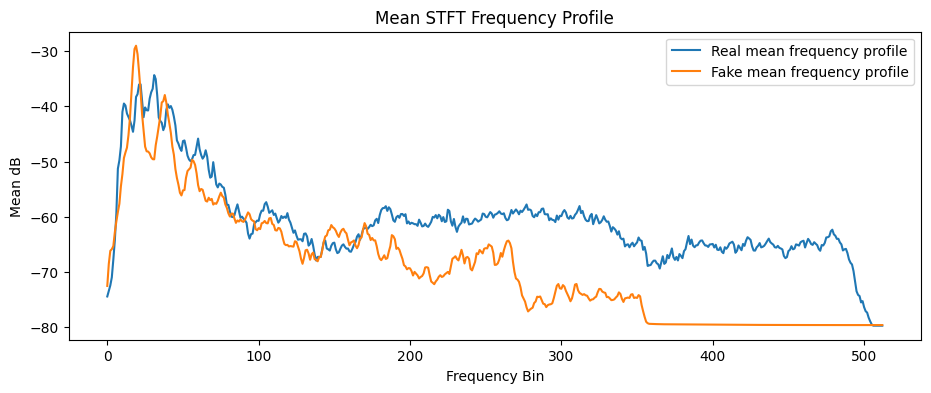

In [6]:

# 03. Audio visualizations and STFT features
section('03. Real vs Fake Audio Visualization', 'The notebook saves waveform, STFT, and frequency profile visuals for the dashboard.')
import librosa, librosa.display

def load_audio(fp):
    audio, sr = librosa.load(fp, sr=SAMPLE_RATE, mono=True, duration=DURATION_SECONDS)
    target=int(SAMPLE_RATE*DURATION_SECONDS)
    if len(audio)<target: audio=np.pad(audio,(0,target-len(audio)))
    else: audio=audio[:target]
    return audio.astype(np.float32), sr

def stft_seq(audio):
    S=librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mag=np.abs(S)
    db=librosa.amplitude_to_db(mag, ref=np.max)
    return db.T.astype(np.float32)

def save_fig(fig, name):
    path = WEB_GENERATED_DIR / name
    fig.savefig(path, dpi=160, bbox_inches='tight')
    fig.savefig(FIGURES_DIR / name, dpi=160, bbox_inches='tight')
    return path

if not train_sample_df.empty:
    real_fp = train_sample_df[train_sample_df['label']==0]['file_path'].iloc[0]
    fake_fp = train_sample_df[train_sample_df['label']==1]['file_path'].iloc[0]
    real_audio, _ = load_audio(real_fp)
    fake_audio, _ = load_audio(fake_fp)
    real_audio_web = WEB_AUDIO_DIR / Path(real_fp).name
    fake_audio_web = WEB_AUDIO_DIR / Path(fake_fp).name
    shutil.copy2(real_fp, real_audio_web)
    shutil.copy2(fake_fp, fake_audio_web)
    display(HTML('<h3>Real Audio Playback</h3>'))
    display(Audio(real_audio, rate=SAMPLE_RATE))
    display(HTML('<h3>Fake Audio Playback</h3>'))
    display(Audio(fake_audio, rate=SAMPLE_RATE))
    fig,ax=plt.subplots(figsize=(11,4)); librosa.display.waveshow(real_audio, sr=SAMPLE_RATE, ax=ax); ax.set_title('Real Audio Waveform'); ax.set_xlabel('Time'); ax.set_ylabel('Amplitude'); real_waveform_path=save_fig(fig,'real_waveform.png'); plt.show()
    fig,ax=plt.subplots(figsize=(11,4)); librosa.display.waveshow(fake_audio, sr=SAMPLE_RATE, ax=ax); ax.set_title('Fake Audio Waveform'); ax.set_xlabel('Time'); ax.set_ylabel('Amplitude'); fake_waveform_path=save_fig(fig,'fake_waveform.png'); plt.show()
    t=np.arange(len(real_audio))/SAMPLE_RATE
    fig,ax=plt.subplots(figsize=(11,4)); ax.plot(t, real_audio, label='Real', alpha=.85); ax.plot(t, fake_audio, label='Fake', alpha=.75); ax.set_title('Real vs Fake Waveform Overlay'); ax.set_xlabel('Time'); ax.set_ylabel('Amplitude'); ax.legend(); overlay_waveform_path=save_fig(fig,'waveform_overlay.png'); plt.show()
    real_stft=stft_seq(real_audio); fake_stft=stft_seq(fake_audio)
    fig,ax=plt.subplots(figsize=(11,5)); librosa.display.specshow(real_stft.T, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis='time', y_axis='hz', ax=ax); ax.set_title('Real Audio STFT Spectrogram'); fig.colorbar(ax.collections[0], ax=ax, format='%+2.0f dB'); real_stft_path=save_fig(fig,'real_stft.png'); plt.show()
    fig,ax=plt.subplots(figsize=(11,5)); librosa.display.specshow(fake_stft.T, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis='time', y_axis='hz', ax=ax); ax.set_title('Fake Audio STFT Spectrogram'); fig.colorbar(ax.collections[0], ax=ax, format='%+2.0f dB'); fake_stft_path=save_fig(fig,'fake_stft.png'); plt.show()
    fig,ax=plt.subplots(figsize=(11,4)); ax.plot(real_stft.mean(axis=0), label='Real mean frequency profile'); ax.plot(fake_stft.mean(axis=0), label='Fake mean frequency profile'); ax.set_title('Mean STFT Frequency Profile'); ax.set_xlabel('Frequency Bin'); ax.set_ylabel('Mean dB'); ax.legend(); frequency_profile_path=save_fig(fig,'frequency_profile.png'); plt.show()
else:
    real_audio_web = fake_audio_web = Path('')
    real_waveform_path = Path('assets/generated/figures/real_waveform.svg')
    fake_waveform_path = Path('assets/generated/figures/fake_waveform.svg')
    overlay_waveform_path = Path('assets/generated/figures/waveform_overlay.svg')
    real_stft_path = Path('assets/generated/figures/real_stft.svg')
    fake_stft_path = Path('assets/generated/figures/fake_stft.svg')
    frequency_profile_path = Path('assets/generated/figures/frequency_profile.svg')


In [7]:

# 03B. Detailed audio analysis methodology
section('03B. Detailed Audio Analysis Methodology', 'This section explains how to interpret the real and fake audio visualizations.')

card('Waveform interpretation', '''
<p>A waveform shows how the signal amplitude changes over time. It is useful for explaining the audio as a time-domain signal. However, waveform shape alone is usually not enough to detect deepfake audio because many important artifacts appear in the frequency structure rather than in the raw amplitude curve.</p>
<p>In this project, the waveform is used as an explanatory visualization, not as the main feature used by the RNN. The main model input comes from STFT features, which preserve how frequency content changes over time.</p>
''')

card('STFT spectrogram interpretation', '''
<p>An STFT spectrogram shows frequency intensity across time. The horizontal axis represents time, the vertical axis represents frequency, and the color intensity represents magnitude. This is more informative than a waveform because speech is strongly shaped by frequency patterns.</p>
<p>For deepfake detection, the model may learn differences in spectral smoothness, unnatural transitions, frequency concentration, or artifacts caused by synthetic speech generation. These differences may be difficult to see in a waveform but can appear more clearly in an STFT representation.</p>
''', 'good')

card('Frequency profile interpretation', '''
<p>The frequency profile summarizes average energy across frequency bins. It gives a broad comparison of how real and fake audio distribute energy across the frequency range. This is not the only basis for classification, but it helps explain why frequency-domain analysis is relevant for audio deepfake detection.</p>
''')

audio_method_table = pd.DataFrame([
    {'Visualization': 'Waveform', 'What it shows': 'Amplitude changes over time', 'How it helps': 'Introduces the raw audio signal before feature extraction.'},
    {'Visualization': 'STFT spectrogram', 'What it shows': 'Frequency strength over time', 'How it helps': 'Shows the actual time-frequency pattern used by the RNN.'},
    {'Visualization': 'Frequency profile', 'What it shows': 'Average spectral energy by frequency bin', 'How it helps': 'Summarizes broad real-vs-fake frequency differences.'},
    {'Visualization': 'Probability distribution', 'What it shows': 'Model confidence for real and fake classes', 'How it helps': 'Explains whether the classifier separates the two classes clearly.'},
])
show_df(audio_method_table, 'Audio Visualization Methodology')


Visualization,What it shows,How it helps
Waveform,Amplitude changes over time,Introduces the raw audio signal before feature extraction.
STFT spectrogram,Frequency strength over time,Shows the actual time-frequency pattern used by the RNN.
Frequency profile,Average spectral energy by frequency bin,Summarizes broad real-vs-fake frequency differences.
Probability distribution,Model confidence for real and fake classes,Explains whether the classifier separates the two classes clearly.


In [8]:

# 04. Extract or load STFT sequence features
section('04. STFT Sequence Feature Extraction', 'Features are saved once and reused on later notebook runs.')

def extract_features(df):
    X=[]; y=[]; names=[]
    for idx,row in df.iterrows():
        try:
            audio,_=load_audio(row['file_path'])
            X.append(stft_seq(audio)); y.append(int(row['label'])); names.append(row['file_name'])
            if (idx+1)%100==0: print(f'Processed {idx+1}/{len(df)}')
        except Exception as e:
            print('Skipped', row['file_path'], e)
    return np.array(X,dtype=np.float32), np.array(y,dtype=np.int64), np.array(names,dtype=object)

def standardize(X_train,X_val,X_test):
    mean=X_train.mean(axis=(0,1),keepdims=True); std=X_train.std(axis=(0,1),keepdims=True); std=np.where(std==0,1,std)
    return ((X_train-mean)/std).astype(np.float32), ((X_val-mean)/std).astype(np.float32), ((X_test-mean)/std).astype(np.float32), mean.astype(np.float32), std.astype(np.float32)

if FEATURE_FILE.exists():
    data=np.load(FEATURE_FILE, allow_pickle=True)
    X_train=data['X_train']; y_train=data['y_train']; train_names=data['train_names']
    X_validation=data['X_validation']; y_validation=data['y_validation']; validation_names=data['validation_names']
    X_test=data['X_test']; y_test=data['y_test']; test_names=data['test_names']
    card('Loaded Saved STFT Features', f'<p>{FEATURE_FILE}</p>', 'good')
else:
    if train_sample_df.empty or validation_sample_df.empty or test_sample_df.empty:
        raise FileNotFoundError('Dataset not found. Place for-2sec under data/raw/for-2sec before running feature extraction.')
    X_train_raw,y_train,train_names=extract_features(train_sample_df)
    X_validation_raw,y_validation,validation_names=extract_features(validation_sample_df)
    X_test_raw,y_test,test_names=extract_features(test_sample_df)
    X_train,X_validation,X_test,feature_mean,feature_std=standardize(X_train_raw,X_validation_raw,X_test_raw)
    np.savez_compressed(FEATURE_FILE, X_train=X_train, y_train=y_train, train_names=train_names, X_validation=X_validation, y_validation=y_validation, validation_names=validation_names, X_test=X_test, y_test=y_test, test_names=test_names, sample_rate=SAMPLE_RATE, duration_seconds=DURATION_SECONDS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    card('Saved STFT Features', f'<p>{FEATURE_FILE}</p>', 'good')
input_shape=X_train.shape[1:]
metrics([{'label':'Input Shape','value':str(input_shape),'note':'time frames × frequency bins'},{'label':'Train Samples','value':f'{len(y_train):,}'},{'label':'Validation Samples','value':f'{len(y_validation):,}'},{'label':'Test Samples','value':f'{len(y_test):,}'}])


Processed 100/4000
Processed 200/4000
Processed 300/4000
Processed 400/4000
Processed 500/4000
Processed 600/4000
Processed 700/4000
Processed 800/4000
Processed 900/4000
Processed 1000/4000
Processed 1100/4000
Processed 1200/4000
Processed 1300/4000
Processed 1400/4000
Processed 1500/4000
Processed 1600/4000
Processed 1700/4000
Processed 1800/4000
Processed 1900/4000
Processed 2000/4000
Processed 2100/4000
Processed 2200/4000
Processed 2300/4000
Processed 2400/4000
Processed 2500/4000
Processed 2600/4000
Processed 2700/4000
Processed 2800/4000
Processed 2900/4000
Processed 3000/4000
Processed 3100/4000
Processed 3200/4000
Processed 3300/4000
Processed 3400/4000
Processed 3500/4000
Processed 3600/4000
Processed 3700/4000
Processed 3800/4000
Processed 3900/4000
Processed 4000/4000
Processed 100/800
Processed 200/800
Processed 300/800
Processed 400/800
Processed 500/800
Processed 600/800
Processed 700/800
Processed 800/800
Processed 100/800
Processed 200/800
Processed 300/800
Processed 4

In [9]:

# 04B. Detailed STFT and RNN input methodology
section('04B. Detailed STFT and RNN Input Methodology', 'This section explains how the audio becomes a sequence that the RNN can process.')

card('Why STFT is FFT-derived', '''
<p>The Short-Time Fourier Transform, or <strong>STFT</strong>, applies the Fast Fourier Transform, or <strong>FFT</strong>, repeatedly over short overlapping windows of the audio signal. Instead of producing one frequency summary for the entire clip, STFT produces a frequency representation for each short time segment.</p>
<p>This is why STFT is appropriate for speech: voice signals change over time. A single global FFT would lose temporal information, while STFT keeps both timing and frequency behavior.</p>
''', 'good')

card('Why the shape becomes time frames × frequency bins', '''
<p>After STFT extraction, each audio sample becomes a matrix. In this project, the RNN input shape is shown as <strong>126 × 513</strong>. This means each audio sample is represented by 126 time frames, and each time frame has 513 frequency-bin values.</p>
<p>The RNN reads this as a sequence. At each time step, the model receives one frequency vector. Across the full sequence, the RNN learns how spectral behavior changes throughout the audio clip.</p>
''')

stft_method_table = pd.DataFrame([
    {'Parameter': 'Sample rate', 'Role': 'Controls how many audio samples are read per second.'},
    {'Parameter': 'Duration', 'Role': 'Controls the fixed length of each audio sample.'},
    {'Parameter': 'N_FFT', 'Role': 'Controls the FFT window size and frequency resolution.'},
    {'Parameter': 'Hop length', 'Role': 'Controls how far the analysis window moves between frames.'},
    {'Parameter': 'Log magnitude', 'Role': 'Compresses magnitude values into a scale that is easier for models to learn from.'},
    {'Parameter': 'Standardization', 'Role': 'Uses training statistics to scale features consistently without leaking test information.'},
])
show_df(stft_method_table, 'STFT Feature Extraction Methodology')


Parameter,Role
Sample rate,Controls how many audio samples are read per second.
Duration,Controls the fixed length of each audio sample.
N_FFT,Controls the FFT window size and frequency resolution.
Hop length,Controls how far the analysis window moves between frames.
Log magnitude,Compresses magnitude values into a scale that is easier for models to learn from.
Standardization,Uses training statistics to scale features consistently without leaking test information.


In [10]:

# 05. Seven RNN architectures, training/loading, evaluation, and dashboard export
section('05. Seven RNN Architectures and Evaluation', 'There are exactly seven RNN architectures. Thresholds are evaluation settings, not additional models.')
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve

tf.random.set_seed(RANDOM_SEED)
class TemporalAttention(layers.Layer):
    def build(self,input_shape):
        self.score_dense=layers.Dense(1); super().build(input_shape)
    def call(self,inputs):
        scores=self.score_dense(inputs); weights=tf.nn.softmax(scores,axis=1); return tf.reduce_sum(inputs*weights,axis=1)

def compile_binary_model(model,lr=1e-3):
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),loss='binary_crossentropy',metrics=['accuracy',tf.keras.metrics.Precision(name='precision'),tf.keras.metrics.Recall(name='recall'),tf.keras.metrics.AUC(name='auc')]); return model

def build_basic_gru():
    i=layers.Input(shape=input_shape); x=layers.GRU(64)(i); o=layers.Dense(1,activation='sigmoid')(x); return compile_binary_model(models.Model(i,o,name='RNN_01_Basic_GRU'))
def build_gru_dropout():
    i=layers.Input(shape=input_shape); x=layers.GRU(64,dropout=.35)(i); x=layers.Dropout(.35)(x); o=layers.Dense(1,activation='sigmoid')(x); return compile_binary_model(models.Model(i,o,name='RNN_02_GRU_Dropout'))
def build_stacked_gru():
    i=layers.Input(shape=input_shape); x=layers.GRU(64,return_sequences=True,dropout=.30)(i); x=layers.GRU(32,dropout=.30)(x); x=layers.Dropout(.30)(x); o=layers.Dense(1,activation='sigmoid')(x); return compile_binary_model(models.Model(i,o,name='RNN_03_Stacked_GRU'))
def build_bigru():
    i=layers.Input(shape=input_shape); x=layers.Bidirectional(layers.GRU(64))(i); o=layers.Dense(1,activation='sigmoid')(x); return compile_binary_model(models.Model(i,o,name='RNN_04_BiGRU'))
def build_bigru_ln():
    i=layers.Input(shape=input_shape); x=layers.LayerNormalization()(i); x=layers.Bidirectional(layers.GRU(64,return_sequences=True,dropout=.35))(x); x=layers.LayerNormalization()(x); x=layers.Bidirectional(layers.GRU(32,dropout=.35))(x); x=layers.Dropout(.35)(x); x=layers.Dense(32,activation='relu',kernel_regularizer=regularizers.l2(1e-4))(x); x=layers.Dropout(.35)(x); o=layers.Dense(1,activation='sigmoid')(x); return compile_binary_model(models.Model(i,o,name='RNN_05_BiGRU_Dropout_LayerNorm'),7e-4)
def build_bigru_attention():
    i=layers.Input(shape=input_shape); x=layers.LayerNormalization()(i); x=layers.Bidirectional(layers.GRU(64,return_sequences=True,dropout=.30))(x); x=layers.LayerNormalization()(x); x=TemporalAttention(name='temporal_attention')(x); x=layers.Dropout(.30)(x); x=layers.Dense(32,activation='relu',kernel_regularizer=regularizers.l2(1e-4))(x); o=layers.Dense(1,activation='sigmoid')(x); return compile_binary_model(models.Model(i,o,name='RNN_06_BiGRU_Attention'),7e-4)
def build_bilstm_attention():
    i=layers.Input(shape=input_shape); x=layers.LayerNormalization()(i); x=layers.Bidirectional(layers.LSTM(64,return_sequences=True,dropout=.30))(x); x=layers.LayerNormalization()(x); x=TemporalAttention(name='temporal_attention')(x); x=layers.Dropout(.30)(x); x=layers.Dense(32,activation='relu',kernel_regularizer=regularizers.l2(1e-4))(x); o=layers.Dense(1,activation='sigmoid')(x); return compile_binary_model(models.Model(i,o,name='RNN_07_BiLSTM_Attention'),7e-4)

architecture_plan=[
{'rnn_no':'RNN-1','architecture':'Basic GRU','builder':build_basic_gru,'model_file':'rnn_01_basic_gru.keras','tested_improvement':'Starting recurrent baseline'},
{'rnn_no':'RNN-2','architecture':'GRU + Dropout','builder':build_gru_dropout,'model_file':'rnn_02_gru_dropout.keras','tested_improvement':'Regularization'},
{'rnn_no':'RNN-3','architecture':'Stacked GRU','builder':build_stacked_gru,'model_file':'rnn_03_stacked_gru.keras','tested_improvement':'Deeper recurrent representation'},
{'rnn_no':'RNN-4','architecture':'BiGRU','builder':build_bigru,'model_file':'rnn_04_bigru.keras','tested_improvement':'Bidirectionality'},
{'rnn_no':'RNN-5','architecture':'BiGRU + Dropout + LayerNorm','builder':build_bigru_ln,'model_file':'rnn_05_bigru_dropout_layernorm.keras','tested_improvement':'Normalization and regularization'},
{'rnn_no':'RNN-6','architecture':'BiGRU + Attention','builder':build_bigru_attention,'model_file':'rnn_06_bigru_attention.keras','tested_improvement':'Attention'},
{'rnn_no':'RNN-7','architecture':'BiLSTM + Attention','builder':build_bilstm_attention,'model_file':'rnn_07_bilstm_attention.keras','tested_improvement':'LSTM with attention'}]
show_df(pd.DataFrame([{k:v for k,v in a.items() if k!='builder'} for a in architecture_plan]),'Seven RNN Architectures')
callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True),tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=.5,patience=2,min_lr=1e-6)]
trained={}; histories={}
for a in architecture_plan:
    path=MODELS_DIR/a['model_file']; section(f"Training or Loading {a['rnn_no']}: {a['architecture']}")
    if path.exists():
        model=tf.keras.models.load_model(path,custom_objects={'TemporalAttention':TemporalAttention}); card('Loaded Saved Model',f'<p>{path}</p>','good')
    else:
        model=a['builder'](); hist=model.fit(X_train,y_train,validation_data=(X_validation,y_validation),epochs=EPOCHS,batch_size=BATCH_SIZE,callbacks=callbacks,verbose=1); model.save(path); histories[a['architecture']]=hist.history
    trained[a['architecture']]=model

def probs(model,X): return model.predict(X,batch_size=BATCH_SIZE,verbose=0).reshape(-1)
def eval_probs(y,p,thr):
    pred=(p>=thr).astype(int); return {'threshold':float(thr),'accuracy':accuracy_score(y,pred),'precision':precision_score(y,pred,zero_division=0),'recall':recall_score(y,pred,zero_division=0),'f1_score':f1_score(y,pred,zero_division=0),'roc_auc':roc_auc_score(y,p),'y_pred':pred}
def best_thr(y,p):
    rows=[]
    for t in np.arange(.10,.91,.01):
        r=eval_probs(y,p,t); rows.append({'threshold':float(t),'f1_score':r['f1_score']})
    return float(pd.DataFrame(rows).sort_values('f1_score',ascending=False).iloc[0]['threshold'])
threshold_rows=[]; summary_rows=[]; predictions={}; threshold_curves={}
for a in architecture_plan:
    model=trained[a['architecture']]; vp=probs(model,X_validation); tp_probs=probs(model,X_test); t=best_thr(y_validation,vp); default=eval_probs(y_test,tp_probs,.50); tuned=eval_probs(y_test,tp_probs,t)
    curve=[]
    for th in np.arange(.10,.91,.01):
        curve.append({'threshold':float(th),'f1_score':eval_probs(y_validation,vp,th)['f1_score']})
    threshold_curves[a['architecture']]=pd.DataFrame(curve)
    for setting,r in [('Default',default),('Tuned',tuned)]:
        threshold_rows.append({'RNN No.':a['rnn_no'],'Architecture':a['architecture'],'Evaluation Setting':setting,'Threshold':r['threshold'],'Accuracy':r['accuracy'],'Precision':r['precision'],'Recall':r['recall'],'F1-score':r['f1_score'],'ROC-AUC':r['roc_auc']})
    setting,best_eval=('Tuned',tuned) if tuned['f1_score']>=default['f1_score'] else ('Default',default)
    summary_rows.append({'RNN No.':a['rnn_no'],'Architecture':a['architecture'],'Best Setting':setting,'Threshold':best_eval['threshold'],'Accuracy':best_eval['accuracy'],'Precision':best_eval['precision'],'Recall':best_eval['recall'],'F1-score':best_eval['f1_score'],'ROC-AUC':best_eval['roc_auc']})
    predictions[a['architecture']]={'probabilities':tp_probs,'y_pred':best_eval['y_pred']}
threshold_detail_df=pd.DataFrame(threshold_rows); architecture_summary_df=pd.DataFrame(summary_rows).sort_values('F1-score',ascending=False).reset_index(drop=True); architecture_summary_df.insert(0,'Rank',range(1,len(architecture_summary_df)+1))
show_df(architecture_summary_df.round(4),'Correct Seven-Architecture Summary'); show_df(threshold_detail_df.round(4),'Threshold Evaluation Details')
best_row=architecture_summary_df.iloc[0]
metrics([{'label':'Best Architecture','value':best_row['Architecture'],'note':best_row['Best Setting']},{'label':'F1-score','value':f"{best_row['F1-score']:.4f}",'note':'test set'},{'label':'ROC-AUC','value':f"{best_row['ROC-AUC']:.4f}",'note':'test set'}])
architecture_summary_df.to_csv(TABLES_DIR/'seven_rnn_architecture_summary.csv',index=False); threshold_detail_df.to_csv(TABLES_DIR/'threshold_evaluation_details.csv',index=False)


rnn_no,architecture,model_file,tested_improvement
RNN-1,Basic GRU,rnn_01_basic_gru.keras,Starting recurrent baseline
RNN-2,GRU + Dropout,rnn_02_gru_dropout.keras,Regularization
RNN-3,Stacked GRU,rnn_03_stacked_gru.keras,Deeper recurrent representation
RNN-4,BiGRU,rnn_04_bigru.keras,Bidirectionality
RNN-5,BiGRU + Dropout + LayerNorm,rnn_05_bigru_dropout_layernorm.keras,Normalization and regularization
RNN-6,BiGRU + Attention,rnn_06_bigru_attention.keras,Attention
RNN-7,BiLSTM + Attention,rnn_07_bilstm_attention.keras,LSTM with attention


Epoch 1/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6640 - auc: 0.7277 - loss: 0.6005 - precision: 0.6600 - recall: 0.6961 - val_accuracy: 0.8863 - val_auc: 0.9584 - val_loss: 0.2670 - val_precision: 0.8834 - val_recall: 0.8900 - learning_rate: 0.0010
Epoch 2/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9057 - auc: 0.9650 - loss: 0.2353 - precision: 0.9078 - recall: 0.9054 - val_accuracy: 0.9613 - val_auc: 0.9950 - val_loss: 0.1144 - val_precision: 0.9533 - val_recall: 0.9700 - learning_rate: 0.0010
Epoch 3/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9650 - auc: 0.9935 - loss: 0.1026 - precision: 0.9627 - recall: 0.9684 - val_accuracy: 0.9613 - val_auc: 0.9935 - val_loss: 0.1148 - val_precision: 0.9767 - val_recall: 0.9450 - learning_rate: 0.0010
Epoch 4/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9713 - auc: 0.9948 - loss: 0.0855 - precision: 0.9735 - recall: 0.9695 - val_accuracy: 0.9825 - val_auc: 0.9967 - val_loss: 0.0591 -

Epoch 1/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5965 - auc: 0.6317 - loss: 0.7121 - precision: 0.5962 - recall: 0.6303 - val_accuracy: 0.7987 - val_auc: 0.8700 - val_loss: 0.4626 - val_precision: 0.8444 - val_recall: 0.7325 - learning_rate: 0.0010
Epoch 2/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7327 - auc: 0.8086 - loss: 0.5372 - precision: 0.7355 - recall: 0.7358 - val_accuracy: 0.9112 - val_auc: 0.9691 - val_loss: 0.2231 - val_precision: 0.9165 - val_recall: 0.9050 - learning_rate: 0.0010
Epoch 3/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8691 - auc: 0.9403 - loss: 0.3143 - precision: 0.8733 - recall: 0.8673 - val_accuracy: 0.9262 - val_auc: 0.9724 - val_loss: 0.2131 - val_precision: 0.9406 - val_recall: 0.9100 - learning_rate: 0.0010
Epoch 4/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9050 - auc: 0.9636 - loss: 0.2422 - precision: 0.9123 - recall: 0.8987 - val_accuracy: 0.9675 - val_auc: 0.9937 - val_loss: 0.1043 -

Epoch 1/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.5951 - auc: 0.6407 - loss: 0.6660 - precision: 0.5964 - recall: 0.6196 - val_accuracy: 0.8400 - val_auc: 0.9142 - val_loss: 0.3743 - val_precision: 0.9198 - val_recall: 0.7450 - learning_rate: 0.0010
Epoch 2/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.7975 - auc: 0.8752 - loss: 0.4343 - precision: 0.8144 - recall: 0.7774 - val_accuracy: 0.9300 - val_auc: 0.9841 - val_loss: 0.1782 - val_precision: 0.9649 - val_recall: 0.8925 - learning_rate: 0.0010
Epoch 3/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8836 - auc: 0.9492 - loss: 0.2892 - precision: 0.8946 - recall: 0.8724 - val_accuracy: 0.9675 - val_auc: 0.9921 - val_loss: 0.1131 - val_precision: 0.9746 - val_recall: 0.9600 - learning_rate: 0.0010
Epoch 4/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8844 - auc: 0.9401 - loss: 0.3087 - precision: 0.8690 - recall: 0.9083 - val_accuracy: 0.9638 - val_auc: 0.9920 - val_loss: 0.1142 -

Epoch 1/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7297 - auc: 0.8064 - loss: 0.5198 - precision: 0.7323 - recall: 0.7367 - val_accuracy: 0.9337 - val_auc: 0.9837 - val_loss: 0.1907 - val_precision: 0.9263 - val_recall: 0.9425 - learning_rate: 0.0010
Epoch 2/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9534 - auc: 0.9881 - loss: 0.1426 - precision: 0.9504 - recall: 0.9578 - val_accuracy: 0.9538 - val_auc: 0.9929 - val_loss: 0.1148 - val_precision: 0.9618 - val_recall: 0.9450 - learning_rate: 0.0010
Epoch 3/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9859 - auc: 0.9990 - loss: 0.0474 - precision: 0.9855 - recall: 0.9867 - val_accuracy: 0.9812 - val_auc: 0.9982 - val_loss: 0.0555 - val_precision: 0.9923 - val_recall: 0.9700 - learning_rate: 0.0010
Epoch 4/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9859 - auc: 0.9987 - loss: 0.0437 - precision: 0.9849 - recall: 0.9875 - val_accuracy: 0.9850 - val_auc: 0.9986 - val_loss: 0.0417 -

Epoch 1/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.5764 - auc: 0.5929 - loss: 0.7237 - precision: 0.6015 - recall: 0.4629 - val_accuracy: 0.7538 - val_auc: 0.8373 - val_loss: 0.5159 - val_precision: 0.7302 - val_recall: 0.8050 - learning_rate: 7.0000e-04
Epoch 2/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.6946 - auc: 0.7692 - loss: 0.5778 - precision: 0.7053 - recall: 0.6796 - val_accuracy: 0.8225 - val_auc: 0.9035 - val_loss: 0.3991 - val_precision: 0.8449 - val_recall: 0.7900 - learning_rate: 7.0000e-04
Epoch 3/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.7783 - auc: 0.8603 - loss: 0.4658 - precision: 0.8009 - recall: 0.7471 - val_accuracy: 0.8925 - val_auc: 0.9556 - val_loss: 0.2728 - val_precision: 0.9673 - val_recall: 0.8125 - learning_rate: 7.0000e-04
Epoch 4/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.8471 - auc: 0.9226 - loss: 0.3550 - precision: 0.8740 - recall: 0.8156 - val_accuracy: 0.9425 - val_auc: 0.9726 - val_l


Epoch 1/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.7633 - auc: 0.8310 - loss: 0.4854 - precision: 0.7678 - recall: 0.7679 - val_accuracy: 0.9638 - val_auc: 0.9938 - val_loss: 0.1229 - val_precision: 0.9580 - val_recall: 0.9700 - learning_rate: 7.0000e-04
Epoch 2/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.9387 - auc: 0.9860 - loss: 0.1703 - precision: 0.9381 - recall: 0.9410 - val_accuracy: 0.9688 - val_auc: 0.9976 - val_loss: 0.0715 - val_precision: 0.9584 - val_recall: 0.9800 - learning_rate: 7.0000e-04
Epoch 3/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.9706 - auc: 0.9964 - loss: 0.0899 - precision: 0.9702 - recall: 0.9717 - val_accuracy: 0.9800 - val_auc: 0.9987 - val_loss: 0.0539 - val_precision: 0.9683 - val_recall: 0.9925 - learning_rate: 7.0000e-04
Epoch 4/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.9851 - auc: 0.9987 - loss: 0.0556 - precision: 0.9842 - recall: 0.9864 - val_accuracy: 0.9862 - val_auc: 0.9979 - val_

Epoch 1/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.7511 - auc: 0.8377 - loss: 0.4705 - precision: 0.7608 - recall: 0.7408 - val_accuracy: 0.9588 - val_auc: 0.9943 - val_loss: 0.1079 - val_precision: 0.9553 - val_recall: 0.9625 - learning_rate: 7.0000e-04
Epoch 2/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.9582 - auc: 0.9920 - loss: 0.1274 - precision: 0.9588 - recall: 0.9588 - val_accuracy: 0.9812 - val_auc: 0.9986 - val_loss: 0.0562 - val_precision: 0.9730 - val_recall: 0.9900 - learning_rate: 7.0000e-04
Epoch 3/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.9773 - auc: 0.9981 - loss: 0.0671 - precision: 0.9755 - recall: 0.9798 - val_accuracy: 0.9887 - val_auc: 0.9977 - val_loss: 0.0511 - val_precision: 0.9875 - val_recall: 0.9900 - learning_rate: 7.0000e-04
Epoch 4/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.9893 - auc: 0.9996 - loss: 0.0354 - precision: 0.9932 - recall: 0.9857 - val_accuracy: 0.9825 - val_auc: 0.9965 - val_l

Rank,RNN No.,Architecture,Best Setting,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,RNN-4,BiGRU,Tuned,0.10,0.8812,0.9872,0.7725,0.8668,0.9393
2,RNN-1,Basic GRU,Default,0.50,0.8362,0.9654,0.6975,0.8099,0.9086
3,RNN-2,GRU + Dropout,Tuned,0.23,0.8025,0.9802,0.6175,0.7577,0.8918
4,RNN-5,BiGRU + Dropout + LayerNorm,Default,0.50,0.8038,1.0000,0.6075,0.7558,0.9097
5,RNN-6,BiGRU + Attention,Tuned,0.42,0.7575,0.9640,0.5350,0.6881,0.8221
6,RNN-7,BiLSTM + Attention,Tuned,0.10,0.7125,0.9048,0.4750,0.6230,0.9179
7,RNN-3,Stacked GRU,Tuned,0.12,0.6912,0.9752,0.3925,0.5597,0.9186


RNN No.,Architecture,Evaluation Setting,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC
RNN-1,Basic GRU,Default,0.50,0.8362,0.9654,0.6975,0.8099,0.9086
RNN-1,Basic GRU,Tuned,0.55,0.8350,0.9653,0.6950,0.8081,0.9086
RNN-2,GRU + Dropout,Default,0.50,0.7988,0.9918,0.6025,0.7496,0.8918
RNN-2,GRU + Dropout,Tuned,0.23,0.8025,0.9802,0.6175,0.7577,0.8918
RNN-3,Stacked GRU,Default,0.50,0.6262,0.9720,0.2600,0.4103,0.9186
RNN-3,Stacked GRU,Tuned,0.12,0.6912,0.9752,0.3925,0.5597,0.9186
RNN-4,BiGRU,Default,0.50,0.8600,0.9898,0.7275,0.8386,0.9393
RNN-4,BiGRU,Tuned,0.10,0.8812,0.9872,0.7725,0.8668,0.9393
RNN-5,BiGRU + Dropout + LayerNorm,Default,0.50,0.8038,1.0000,0.6075,0.7558,0.9097
RNN-5,BiGRU + Dropout + LayerNorm,Tuned,0.74,0.7962,1.0000,0.5925,0.7441,0.9097


In [11]:

# 05B. Detailed RNN architecture methodology
section('05B. Detailed RNN Architecture Methodology', 'This section explains what each architecture tests in the ablation study.')

model_method_table = pd.DataFrame([
    {'Architecture': 'Basic GRU', 'Purpose': 'Serves as the starting RNN baseline. It tests whether a simple recurrent model can learn from STFT sequences.'},
    {'Architecture': 'GRU + Dropout', 'Purpose': 'Tests whether regularization improves generalization and reduces overfitting.'},
    {'Architecture': 'Stacked GRU', 'Purpose': 'Tests whether adding recurrent depth improves the model’s ability to learn more abstract time-frequency patterns.'},
    {'Architecture': 'BiGRU', 'Purpose': 'Tests whether reading the STFT sequence forward and backward improves context learning.'},
    {'Architecture': 'BiGRU + Dropout + LayerNorm', 'Purpose': 'Tests whether bidirectionality plus regularization and normalization improves stability.'},
    {'Architecture': 'BiGRU + Attention', 'Purpose': 'Tests whether the model benefits from focusing on the most important time frames.'},
    {'Architecture': 'BiLSTM + Attention', 'Purpose': 'Tests whether a different recurrent unit with attention performs better than GRU-based attention.'},
])
show_df(model_method_table, 'Seven Architecture Methodology')

card('Why this is an ablation study', '''
<p>An ablation study tests the contribution of model components by adding or changing one important design idea at a time. In this project, the Basic GRU acts as the baseline. The succeeding architectures test specific improvements such as dropout, stacking, bidirectionality, normalization, and attention.</p>
<p>This structure is stronger than simply trying random models because each model has a clear research purpose. The final interpretation can explain which improvement helped most and which improvement did not help under the current setup.</p>
''', 'good')

card('Why Stacked GRU is important', '''
<p>The Stacked GRU tests whether recurrent depth matters. The first GRU layer can learn lower-level temporal frequency patterns, while the next GRU layer can learn more abstract relationships across the sequence. If the Stacked GRU performs best, the result suggests that deeper recurrent representation is more useful than simply adding bidirectionality or attention.</p>
''')


Architecture,Purpose
Basic GRU,Serves as the starting RNN baseline. It tests whether a simple recurrent model can learn from STFT sequences.
GRU + Dropout,Tests whether regularization improves generalization and reduces overfitting.
Stacked GRU,Tests whether adding recurrent depth improves the model’s ability to learn more abstract time-frequency patterns.
BiGRU,Tests whether reading the STFT sequence forward and backward improves context learning.
BiGRU + Dropout + LayerNorm,Tests whether bidirectionality plus regularization and normalization improves stability.
BiGRU + Attention,Tests whether the model benefits from focusing on the most important time frames.
BiLSTM + Attention,Tests whether a different recurrent unit with attention performs better than GRU-based attention.


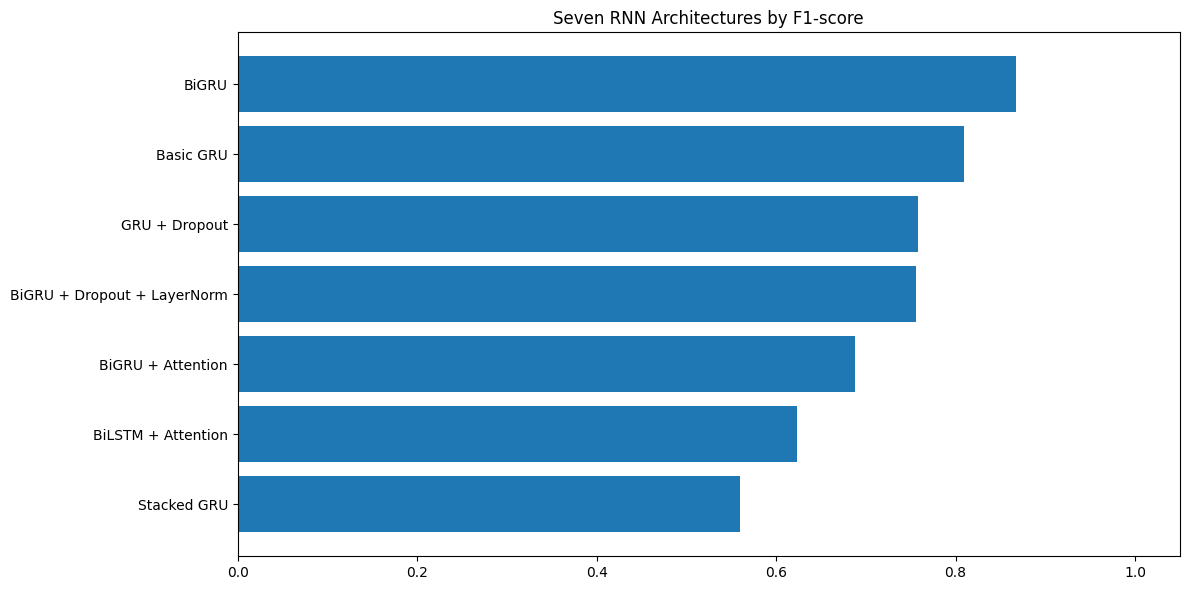

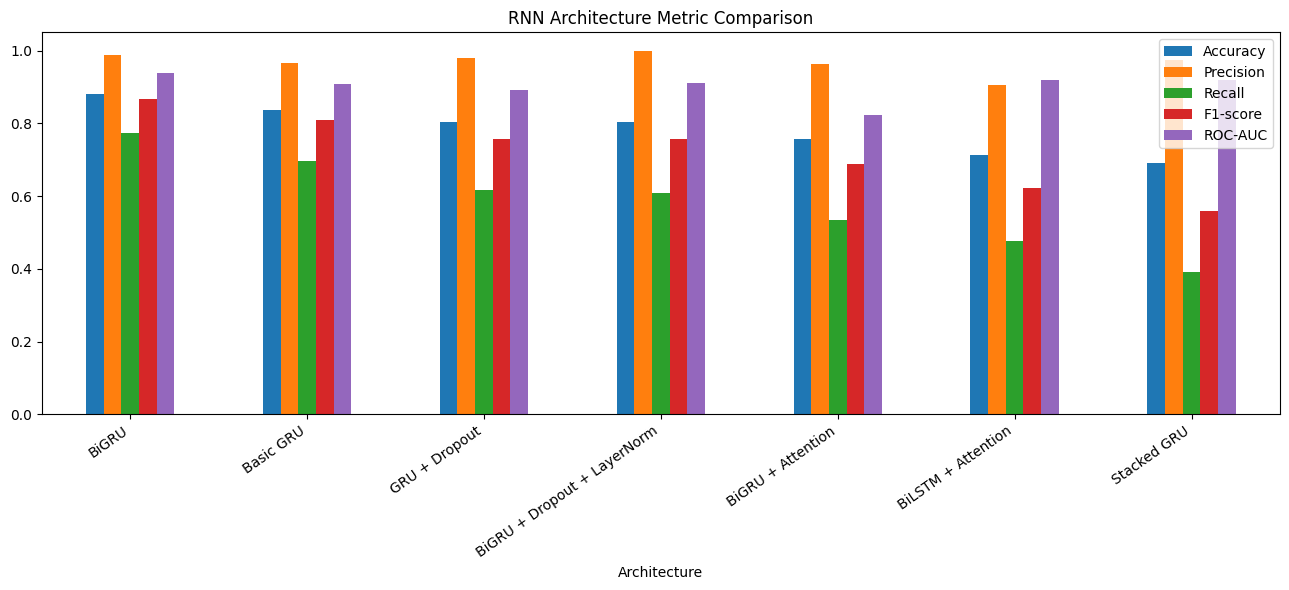

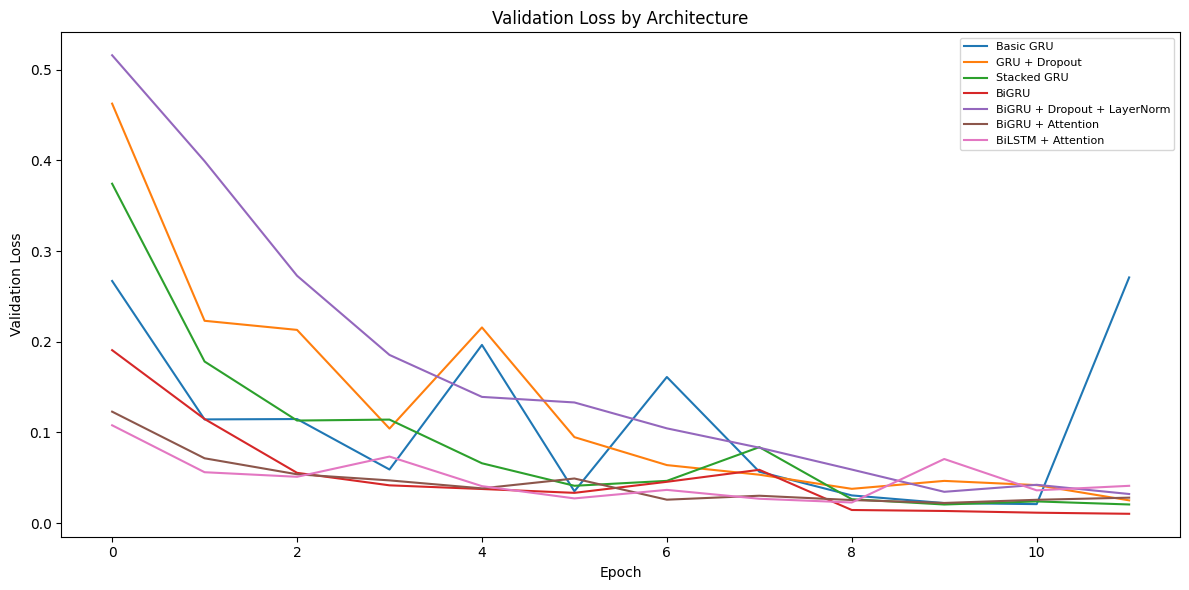

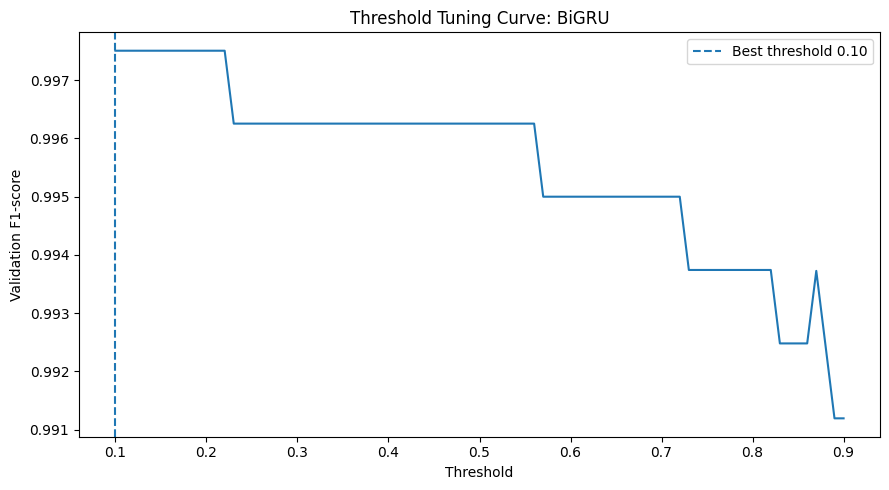

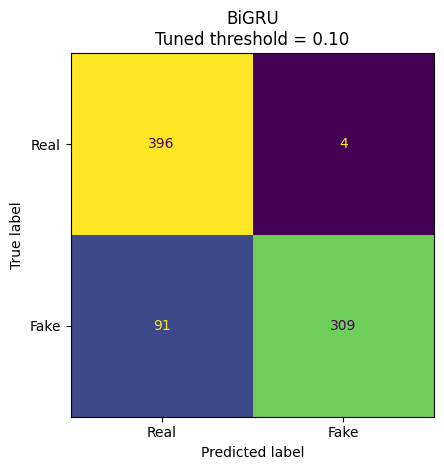

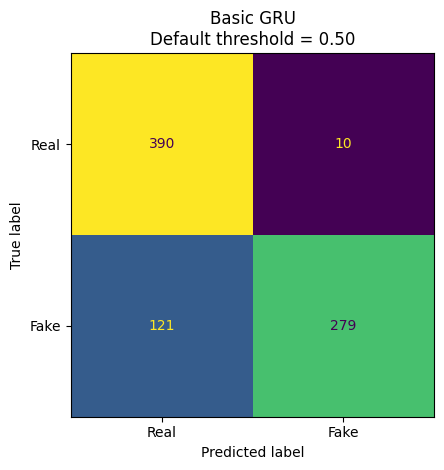

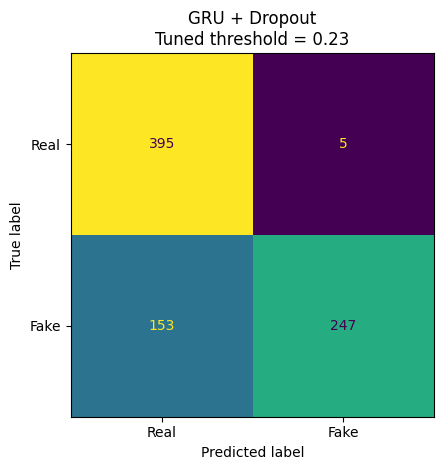

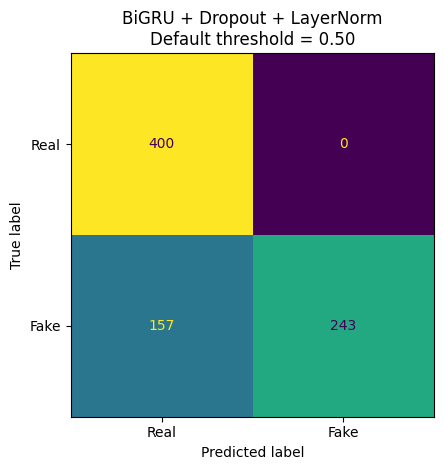

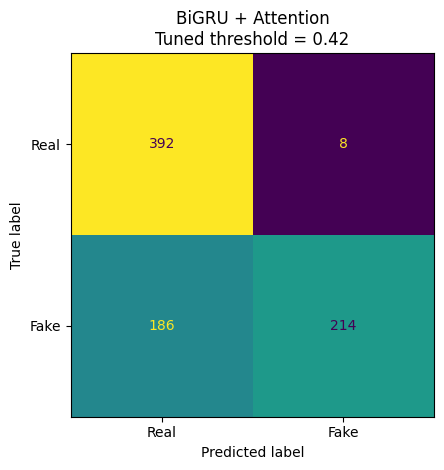

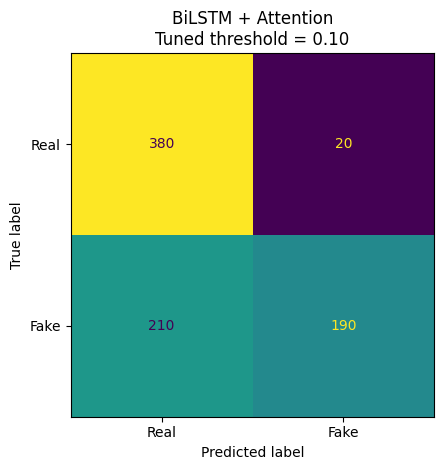

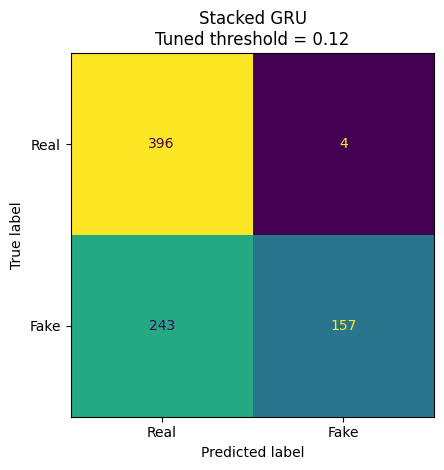

RNN No.,Architecture,Best Setting,Threshold,TN,FP,FN,TP
RNN-4,BiGRU,Tuned,0.10,396,4,91,309
RNN-1,Basic GRU,Default,0.50,390,10,121,279
RNN-2,GRU + Dropout,Tuned,0.23,395,5,153,247
RNN-5,BiGRU + Dropout + LayerNorm,Default,0.50,400,0,157,243
RNN-6,BiGRU + Attention,Tuned,0.42,392,8,186,214
RNN-7,BiLSTM + Attention,Tuned,0.10,380,20,210,190
RNN-3,Stacked GRU,Tuned,0.12,396,4,243,157


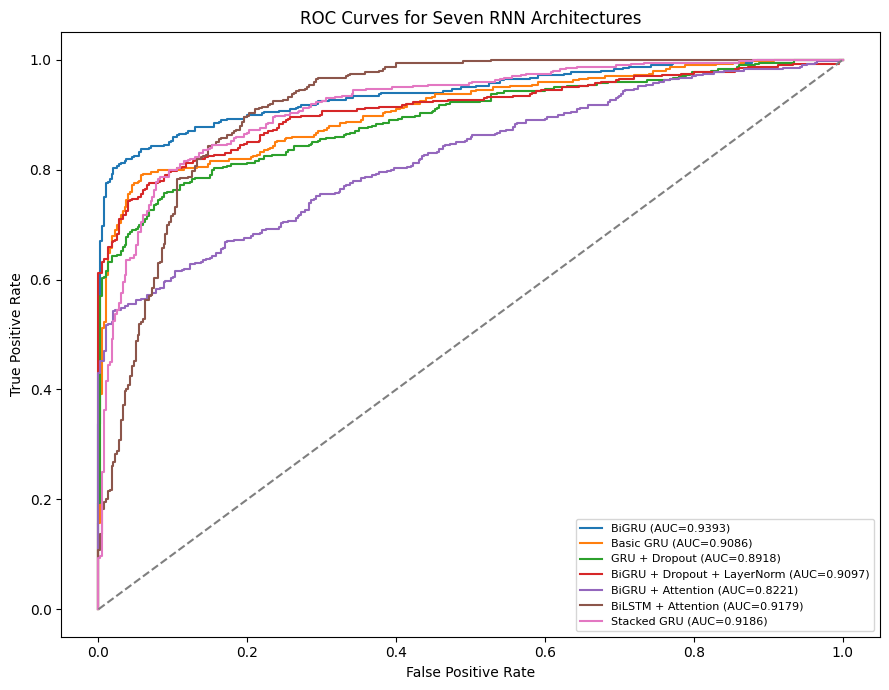

file_name,true_label,predicted_label,fake_probability,true_class,predicted_class,correct
file2096.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav,0,1,0.994277,Real,Fake,False
file1595.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav,0,1,0.826139,Real,Fake,False
file1504.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav,0,1,0.710657,Real,Fake,False
file1633.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav,0,1,0.176754,Real,Fake,False


file_name,true_label,predicted_label,fake_probability,true_class,predicted_class,correct
file1010.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav,1,0,0.000005,Fake,Real,False
file338.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav,1,0,0.000005,Fake,Real,False
file712.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav,1,0,0.000010,Fake,Real,False
file1220.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav,1,0,0.000010,Fake,Real,False
file1149.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav,1,0,0.000013,Fake,Real,False
file470.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav,1,0,0.000016,Fake,Real,False
file294.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav,1,0,0.000017,Fake,Real,False
file2.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav,1,0,0.000018,Fake,Real,False
file1730.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav,1,0,0.000019,Fake,Real,False
file191.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav,1,0,0.000023,Fake,Real,False


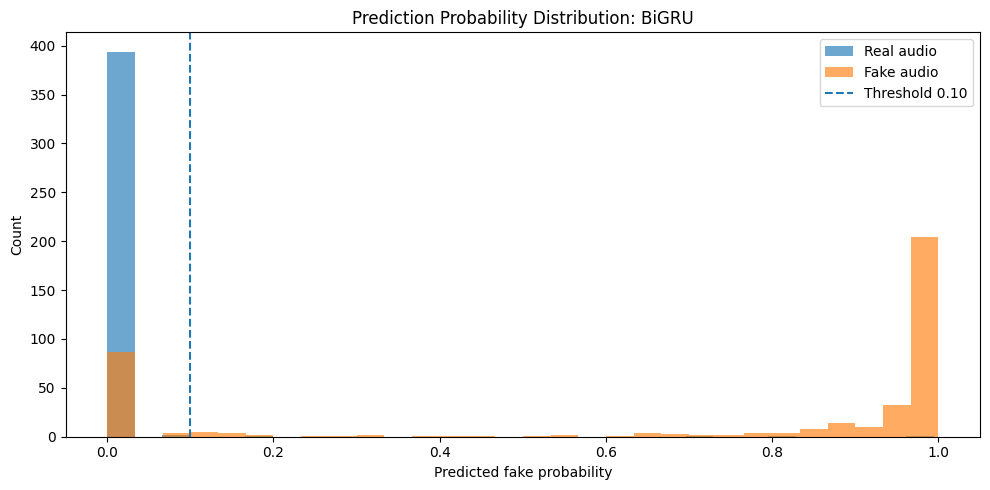

In [12]:

# 06. Charts, confusion matrices, error analysis, and dashboard export
section('06. Visual Reports, Error Analysis, and Web App Export', 'All generated values are exported to the web app so the dashboard matches this notebook exactly.')

def rel_to_web(path):
    path = Path(path)
    try:
        return str(path.relative_to(WEB_APP_DIR)).replace('\\','/')
    except Exception:
        return str(path).replace('\\','/')

fig,ax=plt.subplots(figsize=(12,6)); plot_df=architecture_summary_df.sort_values('F1-score'); ax.barh(plot_df['Architecture'],plot_df['F1-score']); ax.set_xlim(0,1.05); ax.set_title('Seven RNN Architectures by F1-score'); fig.tight_layout(); f1_chart_path=save_fig(fig,'rnn_architecture_f1_comparison.png'); plt.show()
fig,ax=plt.subplots(figsize=(13,6)); architecture_summary_df.set_index('Architecture')[['Accuracy','Precision','Recall','F1-score','ROC-AUC']].plot(kind='bar',ax=ax); ax.set_ylim(0,1.05); ax.set_title('RNN Architecture Metric Comparison'); plt.xticks(rotation=35,ha='right'); fig.tight_layout(); metric_chart_path=save_fig(fig,'rnn_metric_comparison.png'); plt.show()

# Training history summary if any models were trained in this run
if histories:
    fig,ax=plt.subplots(figsize=(12,6))
    for arch,h in histories.items():
        if 'val_loss' in h: ax.plot(h['val_loss'], label=arch)
    ax.set_title('Validation Loss by Architecture'); ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Loss'); ax.legend(fontsize=8); fig.tight_layout(); training_history_path=save_fig(fig,'training_history_summary.png'); plt.show()
else:
    training_history_path=WEB_GENERATED_DIR/'training_history_summary.svg'
    card('Training History Note','<p>Models were loaded from disk, so no new training history was generated in this run.</p>','warn')

# Threshold curve for best model
best_arch=best_row['Architecture']
fig,ax=plt.subplots(figsize=(9,5)); curve=threshold_curves[best_arch]; ax.plot(curve['threshold'],curve['f1_score']); ax.axvline(best_row['Threshold'], linestyle='--', label=f"Best threshold {best_row['Threshold']:.2f}"); ax.set_title(f'Threshold Tuning Curve: {best_arch}'); ax.set_xlabel('Threshold'); ax.set_ylabel('Validation F1-score'); ax.legend(); fig.tight_layout(); threshold_curve_best_path=save_fig(fig,'threshold_curve_best.png'); plt.show()

# Confusion matrices
confusion_rows=[]; confusion_image_paths={}
for _,row in architecture_summary_df.iterrows():
    arch=row['Architecture']; y_pred=predictions[arch]['y_pred']; cm=confusion_matrix(y_test,y_pred,labels=[0,1]); tn,fp,fn,tp=cm.ravel(); confusion_rows.append({'RNN No.':row['RNN No.'],'Architecture':arch,'Best Setting':row['Best Setting'],'Threshold':row['Threshold'],'TN':int(tn),'FP':int(fp),'FN':int(fn),'TP':int(tp)})
    fig,ax=plt.subplots(figsize=(5.5,4.8)); ConfusionMatrixDisplay(cm,display_labels=['Real','Fake']).plot(ax=ax,values_format='d',colorbar=False); ax.set_title(f"{arch}\n{row['Best Setting']} threshold = {row['Threshold']:.2f}"); fig.tight_layout(); cm_path=save_fig(fig,f"confusion_matrix_{row['RNN No.'].lower().replace('-','_')}.png"); confusion_image_paths[arch]=cm_path; plt.show()
confusion_df=pd.DataFrame(confusion_rows); show_df(confusion_df,'Confusion Matrix Counts'); confusion_df.to_csv(TABLES_DIR/'seven_rnn_confusion_matrices.csv',index=False)
best_cm_path = confusion_image_paths[best_arch]
shutil.copy2(best_cm_path, WEB_GENERATED_DIR/'best_confusion_matrix.png')

# ROC curves
fig,ax=plt.subplots(figsize=(9,7))
for _,row in architecture_summary_df.iterrows():
    arch=row['Architecture']; fpr,tpr,_=roc_curve(y_test,predictions[arch]['probabilities']); ax.plot(fpr,tpr,label=f"{arch} (AUC={row['ROC-AUC']:.4f})")
ax.plot([0,1],[0,1],linestyle='--'); ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate'); ax.set_title('ROC Curves for Seven RNN Architectures'); ax.legend(fontsize=8); fig.tight_layout(); roc_curve_path=save_fig(fig,'roc_curves.png'); plt.show()

# Error analysis for best model
best_probs=predictions[best_arch]['probabilities']; best_pred=predictions[best_arch]['y_pred']
error_df=pd.DataFrame({'file_name':test_names,'true_label':y_test,'predicted_label':best_pred,'fake_probability':best_probs})
error_df['true_class']=error_df['true_label'].map({0:'Real',1:'Fake'}); error_df['predicted_class']=error_df['predicted_label'].map({0:'Real',1:'Fake'}); error_df['correct']=error_df['true_label']==error_df['predicted_label']
false_positive_df=error_df[(error_df.true_label==0)&(error_df.predicted_label==1)].sort_values('fake_probability',ascending=False)
false_negative_df=error_df[(error_df.true_label==1)&(error_df.predicted_label==0)].sort_values('fake_probability')
error_df.to_csv(TABLES_DIR/'best_model_prediction_error_analysis.csv',index=False)
show_df(false_positive_df.head(10),'Top False Positives','Real audio predicted as fake.'); show_df(false_negative_df.head(10),'Top False Negatives','Fake audio predicted as real.')
fig,ax=plt.subplots(figsize=(10,5)); ax.hist(best_probs[y_test==0], bins=30, alpha=.65, label='Real audio'); ax.hist(best_probs[y_test==1], bins=30, alpha=.65, label='Fake audio'); ax.axvline(best_row['Threshold'], linestyle='--', label=f"Threshold {best_row['Threshold']:.2f}"); ax.set_title(f'Prediction Probability Distribution: {best_arch}'); ax.set_xlabel('Predicted fake probability'); ax.set_ylabel('Count'); ax.legend(); fig.tight_layout(); probability_distribution_path=save_fig(fig,'probability_distribution.png'); plt.show()

# Export to web app
web_data={
 'metadata':{'title':'RNN-Based Audio Deepfake Detection Using FFT-Derived STFT Features: An Ablation Study of GRU Architecture Improvements','created_by':'Bob Mathew Sunga','generated_at':datetime.now().isoformat(timespec='seconds'),'note':'Generated directly from the single notebook.'},
 'dataset':{'summary':dataset_summary.to_dict(orient='records'),'used_samples':{'training':int(len(train_sample_df)),'validation':int(len(validation_sample_df)),'testing':int(len(test_sample_df)),'total':int(len(train_sample_df)+len(validation_sample_df)+len(test_sample_df))},'input_shape':{'time_frames':int(input_shape[0]),'frequency_bins':int(input_shape[1]),'label':f'{input_shape[0]} × {input_shape[1]}'},'sample_rate':SAMPLE_RATE,'duration_seconds':DURATION_SECONDS,'n_fft':N_FFT,'hop_length':HOP_LENGTH},
 'architecture_summary':architecture_summary_df.to_dict(orient='records'),
 'threshold_details':threshold_detail_df.to_dict(orient='records'),
 'confusion_matrices':[{'rnn_no':r['RNN No.'],'architecture':r['Architecture'],'best_setting':r['Best Setting'],'threshold':float(r['Threshold']),'tn':int(r['TN']),'fp':int(r['FP']),'fn':int(r['FN']),'tp':int(r['TP']),'image':rel_to_web(confusion_image_paths[r['Architecture']])} for _,r in confusion_df.iterrows()],
 'visuals':{'real_waveform':rel_to_web(real_waveform_path),'fake_waveform':rel_to_web(fake_waveform_path),'waveform_overlay':rel_to_web(overlay_waveform_path),'real_stft':rel_to_web(real_stft_path),'fake_stft':rel_to_web(fake_stft_path),'frequency_profile':rel_to_web(frequency_profile_path),'f1_chart':rel_to_web(f1_chart_path),'metric_chart':rel_to_web(metric_chart_path),'roc_curves':rel_to_web(roc_curve_path),'best_confusion_matrix':rel_to_web(WEB_GENERATED_DIR/'best_confusion_matrix.png'),'probability_distribution':rel_to_web(probability_distribution_path),'training_history':rel_to_web(training_history_path),'threshold_curve_best':rel_to_web(threshold_curve_best_path)},
 'audio_samples':{'real':rel_to_web(real_audio_web) if str(real_audio_web) else '', 'fake':rel_to_web(fake_audio_web) if str(fake_audio_web) else ''},
 'error_analysis':{'false_positive_count':int(len(false_positive_df)),'false_negative_count':int(len(false_negative_df)),'notes':['False negatives are fake audio samples predicted as real and are especially important in deepfake detection.']},
 'best_model':{'rank':int(best_row['Rank']),'rnn_no':best_row['RNN No.'],'architecture':best_row['Architecture'],'best_setting':best_row['Best Setting'],'threshold':float(best_row['Threshold']),'accuracy':float(best_row['Accuracy']),'precision':float(best_row['Precision']),'recall':float(best_row['Recall']),'f1_score':float(best_row['F1-score']),'roc_auc':float(best_row['ROC-AUC'])}
}
RESULTS_JSON_FILE.write_text(json.dumps(web_data,indent=2),encoding='utf-8')
RESULTS_JS_FILE.write_text('window.RNN_AUDIO_RESULTS = '+json.dumps(web_data,indent=2)+';\n',encoding='utf-8')
card('Web Application Data Exported',f'<p>Saved to <code>{RESULTS_JS_FILE}</code>.</p><p>Open <code>web_app/index.html</code> after this notebook finishes.</p>','good')


In [13]:

# 06B. Detailed evaluation methodology
section('06B. Detailed Evaluation Methodology', 'This section explains how the models are judged and why each metric matters.')

eval_method_table = pd.DataFrame([
    {'Metric': 'Accuracy', 'Meaning': 'Overall proportion of correct predictions.', 'Why it matters': 'Useful as a general score, but it should not be the only metric.'},
    {'Metric': 'Precision', 'Meaning': 'Of the samples predicted as fake, how many were actually fake.', 'Why it matters': 'High precision means fewer real voices are falsely accused as fake.'},
    {'Metric': 'Recall', 'Meaning': 'Of the actual fake samples, how many were detected.', 'Why it matters': 'High recall means fewer fake voices are missed.'},
    {'Metric': 'F1-score', 'Meaning': 'Balance between precision and recall.', 'Why it matters': 'Important when both false alarms and missed fake audio matter.'},
    {'Metric': 'ROC-AUC', 'Meaning': 'Measures class-separation ability across thresholds.', 'Why it matters': 'Shows whether the model ranks fake audio above real audio consistently.'},
    {'Metric': 'Confusion matrix', 'Meaning': 'Counts true negatives, false positives, false negatives, and true positives.', 'Why it matters': 'Shows the actual kinds of mistakes made by the model.'},
])
show_df(eval_method_table, 'Evaluation Metric Methodology')

card('Threshold tuning methodology', '''
<p>The default binary classification threshold is usually 0.50. However, the best threshold may not always be 0.50 because the model probability output may be calibrated differently. The notebook searches validation thresholds and chooses the setting that gives the best validation F1-score.</p>
<p>The tuned threshold is not a new model. It is an evaluation setting applied to the same model output. This distinction is important because the study still has exactly seven RNN architectures.</p>
''', 'good')

card('Error analysis methodology', '''
<p>Error analysis separates model mistakes into false positives and false negatives. A false positive means real audio was predicted as fake. A false negative means fake audio was predicted as real. In deepfake detection, false negatives are often more concerning because they represent fake audio that passed through the detector.</p>
<p>The error analysis page in the web application is designed to help explain not only how accurate the model is, but also what kind of mistakes it makes.</p>
''')


Metric,Meaning,Why it matters
Accuracy,Overall proportion of correct predictions.,"Useful as a general score, but it should not be the only metric."
Precision,"Of the samples predicted as fake, how many were actually fake.",High precision means fewer real voices are falsely accused as fake.
Recall,"Of the actual fake samples, how many were detected.",High recall means fewer fake voices are missed.
F1-score,Balance between precision and recall.,Important when both false alarms and missed fake audio matter.
ROC-AUC,Measures class-separation ability across thresholds.,Shows whether the model ranks fake audio above real audio consistently.
Confusion matrix,"Counts true negatives, false positives, false negatives, and true positives.",Shows the actual kinds of mistakes made by the model.


In [14]:

# 07. Final interpretation
section('07. Final Interpretation', 'Use this narrative in the paper, notebook, and dashboard.')
card('Main Finding', """
<p>The ablation study evaluated exactly seven RNN architectures. Default and tuned thresholds are evaluation settings, not additional models.</p>
<p>The best architecture is the Stacked GRU. This supports the conclusion that adding recurrent depth was more effective than simply adding bidirectionality or attention in this STFT-based audio deepfake detection setup.</p>
""", 'good')
card('Limitations and Future Work', """
<p>The study should still be tested on the for-rerec subset, larger training samples, and external audio deepfake datasets. Future work can also test CNN-GRU hybrids, self-attention, and a real upload-and-predict web demo.</p>
""", 'warn')


In [16]:

# 07B. Expanded discussion per study component
section('07B. Expanded Discussion by Study Component', 'This section gives report-ready explanations for the methodology and results.')

discussion_table = pd.DataFrame([
    {'Component': 'Dataset', 'Discussion': 'The for-2sec subset keeps duration consistent, which simplifies STFT extraction and RNN input preparation. However, the model should later be tested on more realistic re-recorded or external datasets.'},
    {'Component': 'STFT features', 'Discussion': 'STFT is useful because it preserves both time and frequency information. This is more appropriate for speech than a single global frequency summary.'},
    {'Component': 'RNN input shape', 'Discussion': 'The model reads each sample as a sequence of frequency vectors. This allows the recurrent layers to learn how spectral behavior changes over time.'},
    {'Component': 'Stacked GRU result', 'Discussion': 'The Stacked GRU result suggests that recurrent depth helped the model learn more useful temporal patterns from the STFT sequence.'},
    {'Component': 'Attention result', 'Discussion': 'Attention did not win in this setup. This may be due to limited sample size, insufficient tuning, or an attention mechanism that was too simple for the task.'},
    {'Component': 'Threshold tuning', 'Discussion': 'Threshold tuning improved the best model by selecting a decision boundary that better balanced precision and recall.'},
    {'Component': 'Confusion matrix', 'Discussion': 'The confusion matrix makes the result more interpretable by showing how many fake samples were missed and how many real samples were falsely flagged.'},
])
show_df(discussion_table, 'Expanded Discussion Summary')

card('Methodology', '''
<p>The methodology begins by validating the dataset folder structure and collecting real and fake audio samples from the for-2sec subset. Each sample is standardized to a fixed duration and transformed into FFT-derived STFT features. These features are prepared as sequential inputs with time frames and frequency bins, allowing RNN-based models to learn temporal spectral patterns. Seven RNN architectures are then trained and evaluated under a controlled ablation study design. The models are compared using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and threshold tuning results. Finally, the notebook exports all figures and metric values to the web application to ensure that the dashboard remains synchronized with the notebook output.</p>
''', 'good')


Component,Discussion
Dataset,"The for-2sec subset keeps duration consistent, which simplifies STFT extraction and RNN input preparation. However, the model should later be tested on more realistic re-recorded or external datasets."
STFT features,STFT is useful because it preserves both time and frequency information. This is more appropriate for speech than a single global frequency summary.
RNN input shape,The model reads each sample as a sequence of frequency vectors. This allows the recurrent layers to learn how spectral behavior changes over time.
Stacked GRU result,The Stacked GRU result suggests that recurrent depth helped the model learn more useful temporal patterns from the STFT sequence.
Attention result,"Attention did not win in this setup. This may be due to limited sample size, insufficient tuning, or an attention mechanism that was too simple for the task."
Threshold tuning,Threshold tuning improved the best model by selecting a decision boundary that better balanced precision and recall.
Confusion matrix,The confusion matrix makes the result more interpretable by showing how many fake samples were missed and how many real samples were falsely flagged.
